In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import rv_continuous

In [2]:
PDF_X = np.linspace(0, 200, 1000)
trapezoid = np.trapz

In [3]:
class AsymmetricGaussian(rv_continuous):
    """
    Custom Asymmetric Gaussian distribution.
    Use loc for the mean, and unc_minus/unc_plus as shape parameters.
    """
    def _pdf(self, x, unc_minus, unc_plus):
        """x is already shifted by loc internally by scipy"""
        pdf = np.where(
            x < 0,
            np.exp(-0.5 * (x / unc_minus)**2),
            np.exp(-0.5 * (x / unc_plus)**2)
        )
        
        norm = np.sqrt(2 / (np.pi * (unc_plus + unc_minus)**2))
        return norm * pdf

    def _rvs(self, unc_minus, unc_plus, size=None, random_state=None):
        """Generate random samples from the asymmetric Gaussian"""
        rng = np.random.default_rng()
        # To match _pdf, each side must carry mass unc/(unc_minus + unc_plus),
        # not 50/50: pick the side first, then draw a half-normal on that side
        left = rng.random(size) < unc_minus / (unc_minus + unc_plus)
        half = np.abs(rng.standard_normal(size))
        samples = np.where(left, -half * unc_minus, half * unc_plus)
        return samples

ag = AsymmetricGaussian()

In [4]:
base_loc = 100
base_std = 5
base_pdf = ag.pdf(PDF_X, loc=base_loc, unc_minus=base_std, unc_plus=base_std)

test_pdfs = dict(
    base_pdf = dict(loc=100,unc_minus=5, unc_plus=5),
    deltafunc_pdf = dict(loc=100, unc_minus=1, unc_plus=1),
    deltafunc_slightly_offset_pdf = dict(loc=105, unc_minus=1, unc_plus=1),
    deltafunc_offset_pdf = dict(loc=150, unc_minus=1, unc_plus=1),
    wide_pdf = dict(loc=100,unc_minus=10, unc_plus=10),
    wide_slightly_offset_pdf = dict(loc=105, unc_minus=10, unc_plus=10),
    wide_pdf_offset = dict(loc=115, unc_minus=10, unc_plus=10),
    wide_pdf_veryoffset = dict(loc=150,unc_minus=10, unc_plus=10),
    verywide_pdf = dict(loc=100,unc_minus=50, unc_plus=50),
    verywide_slightly_offset_pdf = dict(loc=105,unc_minus=50, unc_plus=50),
    verywide_pdf_offset = dict(loc=150,unc_minus=50, unc_plus=50),
    asymmetric_pdf_deltafunc = dict(loc=100, unc_minus=0.5, unc_plus=1),
    asymmetric_pdf_deltafunc_offset = dict(loc=150, unc_minus=0.5, unc_plus=1),
    asymmetric_pdf_wide = dict(loc=100, unc_minus=7.5, unc_plus=12.5),
    asymmetric_pdf_wide_offset = dict(loc=150, unc_minus=7.5, unc_plus=12.5),
    asymmetric_pdf_wide_offset_neg = dict(loc=50, unc_minus=7.5, unc_plus=12.5),
    asymmetric_pdf_very_skewed = dict(loc=100, unc_minus=50, unc_plus=1),
    asymmetric_pdf_very_skewed_offset = dict(loc=120, unc_minus=50, unc_plus=1),
    asymmetric_pdf_very_skewed_very_offset_pos = dict(loc=180, unc_minus=50, unc_plus=1),
    asymmetric_pdf_very_skewed_very_offset_neg = dict(loc=(100-80), unc_minus=50, unc_plus=1),
    asymmetric_pdf_very_skewed_slightly_offset_neg = dict(loc=95, unc_minus=50, unc_plus=1),
    asymmetric_pdf_very_skewed_moderately_offset_neg = dict(loc=92, unc_minus=50, unc_plus=1),
    # Straddles the GW: mode below (-6) with a narrow lower tail (unc_minus=1)
    # facing the GW and a wide upper tail (unc_plus=15) pointing away. The median
    # lands just above the GW, so v4 scores it on the narrow facing tail ALONE
    # and ignores the large far-side uncertainty; v2 blends both tails in. This
    # is the structure that maximizes the v2-vs-v4 disagreement.
    asymmetric_v4_straddle = dict(loc=94, unc_minus=1, unc_plus=15),
)

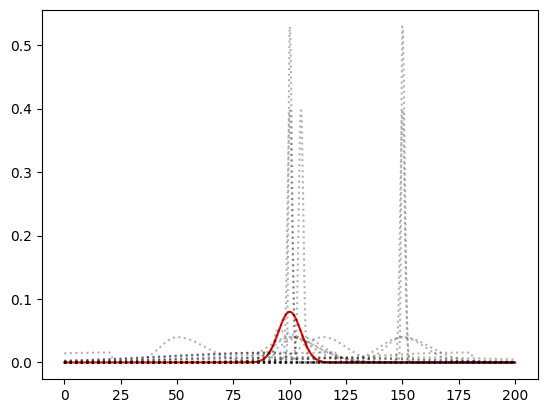

In [5]:
fig, ax = plt.subplots()

ax.plot(PDF_X, base_pdf, color="r")

for label, test_params in test_pdfs.items():
    test = ag.pdf(PDF_X, **test_params)
    ax.plot(PDF_X, test, color="k", alpha=0.3, linestyle=":")

In [32]:
from scipy.special import erf, erfc

# TODO: New stuff to mess around with
def normalization_prefactor(mean_gw, sigma_gw, mean_cand, sigma_cand_neg, sigma_cand_pos):
    prefactor_cand = np.sqrt(2/np.pi) * (sigma_cand_pos + sigma_cand_neg*erf(mean_cand/(sigma_cand_neg*np.sqrt(2))))**-1
    prefactor_gw = float(sigma_gw)**-1 * np.sqrt(2/np.pi) * (1 + erf(mean_gw/(sigma_gw*np.sqrt(2))))**-1
    return np.sqrt(prefactor_cand*prefactor_gw)

def a(sigma_gw, sigma_cand):
    return 1/sigma_gw**2 + 1/sigma_cand**2
        
def b(mean_gw, sigma_gw, mean_cand, sigma_cand):
    return mean_gw/sigma_gw**2 + mean_cand/sigma_cand**2

def c(mean_gw, sigma_gw, mean_cand, sigma_cand):
    return (mean_gw/sigma_gw)**2 + (mean_cand/sigma_cand)**2

def p(_a, _b, _c):
    return np.sqrt(np.pi/_a) * np.exp(-0.25*(_c - _b**2/_a))

def bc_integral_neg(mean_gw, sigma_gw, mean_cand, sigma_cand_neg):
    _a = a(sigma_gw, sigma_cand_neg)
    _b = b(mean_gw, sigma_gw, mean_cand, sigma_cand_neg)
    _c = c(mean_gw, sigma_gw, mean_cand, sigma_cand_neg)

    _p = p(_a, _b, _c)
    x0 = erf(-_b/(2*np.sqrt(_a)))
    x1 = erf(np.sqrt(_a)/2 * (mean_cand - _b/_a))
    return _p*(x1-x0)

def bc_integral_pos(mean_gw, sigma_gw, mean_cand, sigma_cand_pos):
    _a = a(sigma_gw, sigma_cand_pos)
    _b = b(mean_gw, sigma_gw, mean_cand, sigma_cand_pos)
    _c = c(mean_gw, sigma_gw, mean_cand, sigma_cand_pos)

    _p = p(_a, _b, _c)
    return _p*erfc(np.sqrt(_a)/2 * (mean_cand - _b/_a))

def bc(mean_gw, sigma_gw, mean_cand, sigma_cand_neg, sigma_cand_pos):
    lower_args = (mean_gw, sigma_gw, mean_cand, sigma_cand_neg)
    upper_args = (mean_gw, sigma_gw, mean_cand, sigma_cand_pos)
    norm = normalization_prefactor(mean_gw, sigma_gw, mean_cand, sigma_cand_neg, sigma_cand_pos)
    # Shouldn't this be averaged, not naively summed?
    return norm*(bc_integral_neg(*lower_args) + bc_integral_pos(*upper_args))

# TODO: What is the impact of this k parameter in the distance scoring? 
def sigmoid(x, k=1):
    return 1 / (1 + np.exp(-k * x))

def smooth_tophat(x, a, b, k=1):
    return sigmoid(x - a, k) * (1 - sigmoid(x - b, k))

# n_sigma is the range that is considered right now
def smooth_tophat_score(galaxy_dist, gw_mean, gw_std, nsigma=2):
    return smooth_tophat(galaxy_dist, gw_mean-nsigma*gw_std, gw_mean+nsigma*gw_std)

def tophat_score(galaxy_dist, gw_mean, gw_std, nsigma=2,
                 cliff=5.0,            # sigma where the steep drop happens
                 cliff_steepness=4,    # super-Gaussian order; higher = flatter top, sharper cliff
                 box_edge_score=0.95,  # target score at +/- nsigma (sets the in-box gradient)
                 tail_weight=0.02,     # residual floor so distant candidates stay distinct
                 tail_scale=6.0):      # sigma-scale of the heavy tail
    z = (galaxy_dist - gw_mean) / gw_std
    u = np.abs(z)
    alpha = -np.log(box_edge_score) / nsigma**2
    tilt = np.exp(-alpha * u**2)                       # (A) gentle in-box gradient
    core = np.exp(-(u / cliff)**(2 * cliff_steepness)) # (B) flat plateau + steep cliff
    tail = 1.0 / (1.0 + (u / tail_scale)**2)           # (C) heavy tail
    return (1.0 - tail_weight) * tilt * core + tail_weight * tail

# ---------------------------------------------------------------------------
# Weighting schemes: how much to trust the BC overlap term vs the top-hat.
#   r = mean(sigma_cand) / sigma_gw   (small for spec-z, large for photo-z)
#   w -> 0 : score dominated by the top-hat (sharp localisation, spec-z)
#   w -> 1 : score dominated by the BC overlap (broad PDF, photo-z)
# weight_linear reproduces the original min(1, r): linear then a hard clip.
# The others are smooth / non-linear alternatives to experiment with.
# ---------------------------------------------------------------------------
def _sigma_ratio(gw_std, sigma_minus, sigma_plus):
    return np.mean([sigma_minus, sigma_plus], axis=0) / gw_std

def weight_linear(gw_std, sigma_minus, sigma_plus):
    r = _sigma_ratio(gw_std, sigma_minus, sigma_plus)
    return np.minimum(1.0, r)                                   # original behaviour

def weight_hill(gw_std, sigma_minus, sigma_plus, n=2, r_half=1.0):
    # Smooth saturating ramp, no kink: w=0.5 at r=r_half, -> 1 as r grows.
    r = _sigma_ratio(gw_std, sigma_minus, sigma_plus)
    return r**n / (r**n + r_half**n)

def weight_tanh(gw_std, sigma_minus, sigma_plus, scale=1.0):
    r = _sigma_ratio(gw_std, sigma_minus, sigma_plus)
    return np.tanh(r / scale)

def weight_logistic(gw_std, sigma_minus, sigma_plus, r0=1.0, k=4.0):
    # Soft threshold: stays ~0 (trust top-hat) until r ~ r0, then switches on.
    r = _sigma_ratio(gw_std, sigma_minus, sigma_plus)
    return 1.0 / (1.0 + np.exp(-k * (r - r0)))

def hybrid(gw_mean, galaxy_mean, gw_std, galaxy_std_minus, galaxy_std_plus, verbose=True):

    if galaxy_std_minus == 0 or galaxy_std_plus == 0:
        bc_score = 0 # this score should be computed in the sigmoid regime
    else:
        bc_score = bc(gw_mean, gw_std, galaxy_mean, galaxy_std_minus, galaxy_std_plus)

    ts = smooth_tophat_score(galaxy_mean, gw_mean, gw_std)

    # What is the reason why this specifically and not gw_std**2 or something non-linear with the uncertainties?
    # this weight will be small for spec-z's and large for photo-z's   
    w = np.mean([galaxy_std_minus, galaxy_std_plus], axis=0) / gw_std
    max_w = np.ones(w.shape)
    w = np.min([max_w, w], axis=0)

    if verbose:
        print(f"\tBC={bc_score}", f"S={ts}", f"w={w}", f"score={(1-w)*ts + w*bc_score}")

    return np.clip((1-w)*ts + w*bc_score, 0, 1)

def hybrid_v2(gw_mean, galaxy_mean, gw_std, galaxy_std_minus, galaxy_std_plus,
              weight_fn=weight_linear, verbose=True):
    if galaxy_std_minus == 0 or galaxy_std_plus == 0:
        bc_score = 0 # this score should be computed in the sigmoid regime
    else:
        bc_score = bc(gw_mean, gw_std, galaxy_mean, galaxy_std_minus, galaxy_std_plus)

    ts = tophat_score(galaxy_mean, gw_mean, gw_std)

    # Swap weight_fn to try non-linear weightings (weight_hill / weight_tanh /
    # weight_logistic). weight_linear reproduces the original clipped ramp.
    w = np.clip(weight_fn(gw_std, galaxy_std_minus, galaxy_std_plus), 0.0, 1.0)

    # Bhattacharya Coefficient is good
    # Non-linear weighting and tophat scoring needs improvement
    if verbose:
        print(f"\tBC={bc_score}", f"S={ts}", f"w={w}", f"score={(1-w)*ts + w*bc_score}")

    return np.clip((1-w)*ts + w*bc_score, 0, 1)

test                                               hybrid  hybrid_v2      diff      w
-------------------------------------------------------------------------------------
base_pdf                                          1.00000    1.00000  +0.00000   1.00
deltafunc_pdf                                     0.92396    0.92403  -0.00007   0.20
deltafunc_slightly_offset_pdf                     0.89218    0.88711  +0.00507   0.20
deltafunc_offset_pdf                              0.00000    0.00424  -0.00424   0.20
wide_pdf                                          0.89443    0.89443  +0.00000   1.00
wide_slightly_offset_pdf                          0.85081    0.85081  +0.00000   1.00
wide_pdf_offset                                   0.57031    0.57031  +0.00000   1.00
wide_pdf_veryoffset                               0.00603    0.00603  +0.00000   1.00
verywide_pdf                                      0.45014    0.45014  +0.00000   1.00
verywide_slightly_offset_pdf                      0.44

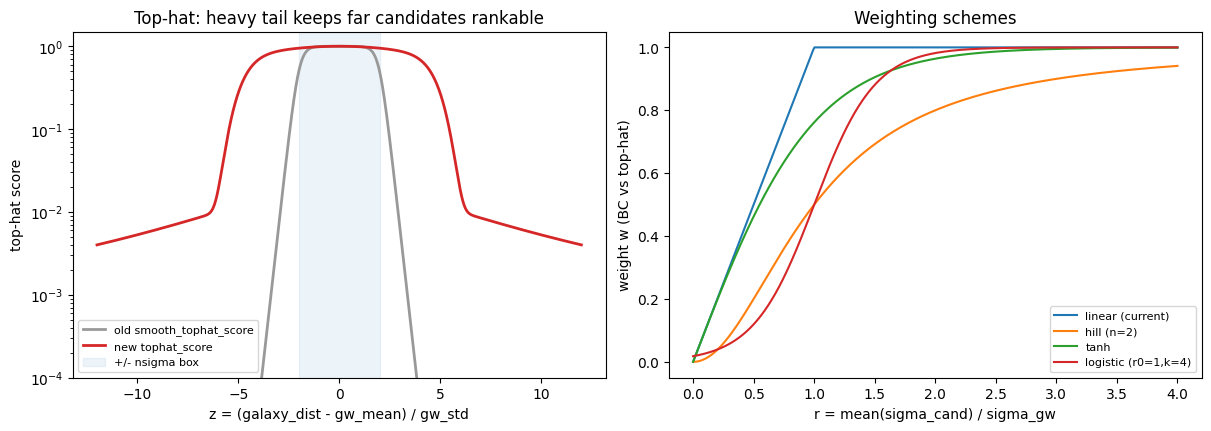

In [33]:
# ==========================================================================
# Diagnostics: hybrid (old top-hat) vs hybrid_v2 (new top-hat), and the
# effect of the different weighting schemes. All quiet (verbose=False).
# ==========================================================================
import os
os.makedirs("hybrid_new/diagnostics", exist_ok=True)

# ---- 1. score table: hybrid vs hybrid_v2 + difference -------------------
print(f"{'test':<48}{'hybrid':>9}{'hybrid_v2':>11}{'diff':>10}{'w':>7}")
print("-" * 85)
for label, t in test_pdfs.items():
    h = hybrid(base_loc, t['loc'], base_std, t['unc_minus'], t['unc_plus'], verbose=False)
    v = hybrid_v2(base_loc, t['loc'], base_std, t['unc_minus'], t['unc_plus'], verbose=False)
    w = float(weight_linear(base_std, t['unc_minus'], t['unc_plus']))
    print(f"{label:<48}{float(h):>9.5f}{float(v):>11.5f}{float(h - v):>+10.5f}{w:>7.2f}")

# ---- 2. weighting-scheme comparison on representative cases --------------
schemes = {'linear': weight_linear, 'hill': weight_hill,
           'tanh': weight_tanh, 'logistic': weight_logistic}
print(f"\n{'test':<40}{'r':>6}" + "".join(f"{s:>10}" for s in schemes))
for label in ['deltafunc_pdf', 'deltafunc_slightly_offset_pdf', 'asymmetric_pdf_deltafunc',
              'wide_pdf', 'wide_slightly_offset_pdf', 'verywide_pdf', 'asymmetric_v4_straddle']:
    t = test_pdfs[label]
    r = float(weight_linear(base_std, t['unc_minus'], t['unc_plus']))  # note: linear is clipped
    r_raw = (t['unc_minus'] + t['unc_plus']) / 2 / base_std
    row = [float(hybrid_v2(base_loc, t['loc'], base_std, t['unc_minus'], t['unc_plus'],
                           weight_fn=wf, verbose=False)) for wf in schemes.values()]
    print(f"{label:<40}{r_raw:>6.2f}" + "".join(f"{x:>10.4f}" for x in row))

# ---- 3. plot the top-hats and the weighting curves ----------------------
z = np.linspace(-12, 12, 2000)
dist = base_loc + z * base_std

fig, (axL, axR) = plt.subplots(1, 2, figsize=(12, 4.2), constrained_layout=True)

axL.plot(z, [smooth_tophat_score(d, base_loc, base_std) for d in dist],
         label="old smooth_tophat_score", color="0.6", lw=2)
axL.plot(z, [tophat_score(d, base_loc, base_std) for d in dist],
         label="new tophat_score", color="C3", lw=2)
axL.axvspan(-2, 2, color="C0", alpha=0.08, label="+/- nsigma box")
axL.set_xlabel("z = (galaxy_dist - gw_mean) / gw_std")
axL.set_ylabel("top-hat score")
axL.set_yscale("log")
axL.set_ylim(1e-4, 1.5)
axL.set_title("Top-hat: heavy tail keeps far candidates rankable")
axL.legend(fontsize=8)

r = np.linspace(0, 4, 400)
sig = base_std
axR.plot(r, [float(weight_linear(sig, ri*sig, ri*sig)) for ri in r], label="linear (current)")
axR.plot(r, [float(weight_hill(sig, ri*sig, ri*sig)) for ri in r], label="hill (n=2)")
axR.plot(r, [float(weight_tanh(sig, ri*sig, ri*sig)) for ri in r], label="tanh")
axR.plot(r, [float(weight_logistic(sig, ri*sig, ri*sig)) for ri in r], label="logistic (r0=1,k=4)")
axR.set_xlabel("r = mean(sigma_cand) / sigma_gw")
axR.set_ylabel("weight w (BC vs top-hat)")
axR.set_title("Weighting schemes")
axR.legend(fontsize=8)

fig.savefig("hybrid_new/diagnostics/tophat_and_weighting.png", dpi=150, bbox_inches="tight")
plt.show()


In [34]:
for label, test in test_pdfs.items():
    test_pdf = ag.pdf(PDF_X, **test)
    print(label)

    # Normalization
    test_pdf = test_pdf / np.sum(test_pdf)
    base_pdf = base_pdf / np.sum(base_pdf)

    final_score = hybrid_v2(base_loc, test['loc'], base_std, test['unc_minus'], test['unc_plus'])

    fig, ax = plt.subplots(figsize=(6, 4), constrained_layout=True)
    ax.plot(PDF_X, base_pdf, color="r", label="Sample GW PDF", alpha=0.5)
    ax.plot(PDF_X, test_pdf, color="k", label="Sample Host PDF", alpha=0.5)
    ax.legend()
    ax.set_title(f"{label}\nFinal Score: {final_score}", pad=12)
    fig.savefig(f"hybrid_new/v2/{label}.png", dpi=300, bbox_inches="tight")
    plt.close(fig)

base_pdf
	BC=1.0000000000000002 S=1.0 w=1.0 score=1.0000000000000002
deltafunc_pdf
	BC=0.6201736729460423 S=1.0 w=0.2 score=0.9240347345892085
deltafunc_slightly_offset_pdf
	BC=0.48765829288336193 S=0.9869703566317976 w=0.2 score=0.8871079438821106
deltafunc_offset_pdf
	BC=2.252901096617221e-11 S=0.005294117647058823 w=0.2 score=0.0042352941221528604
wide_pdf
	BC=0.894427190999916 S=1.0 w=1.0 score=0.894427190999916
wide_slightly_offset_pdf
	BC=0.8508054621526306 S=0.9869703566317976 w=1.0 score=0.8508054621526306
wide_pdf_offset
	BC=0.5703119565575377 S=0.8746372155374821 w=1.0 score=0.5703119565575377
wide_pdf_veryoffset
	BC=0.006026603007498328 S=0.005294117647058823 w=1.0 score=0.006026603007498328
verywide_pdf
	BC=0.4501440362040477 S=1.0 w=1.0 score=0.4501440362040477
verywide_slightly_offset_pdf
	BC=0.44791293302122903 S=0.9869703566317976 w=1.0 score=0.44791293302122903
verywide_pdf_offset
	BC=0.3476554175766578 S=0.005294117647058823 w=1.0 score=0.3476554175766578
asymmetric_p

In [9]:
for label, test in test_pdfs.items():
    test_pdf = ag.pdf(PDF_X, **test)

    # Normalization
    test_pdf = test_pdf / np.sum(test_pdf)
    base_pdf = base_pdf / np.sum(base_pdf)

    final_score = hybrid(base_loc, test['loc'], base_std, test['unc_minus'], test['unc_plus'])

    fig, ax = plt.subplots(figsize=(6, 4), constrained_layout=True)
    ax.plot(PDF_X, base_pdf, color="r", label="Sample GW PDF", alpha=0.5)
    ax.plot(PDF_X, test_pdf, color="k", label="Sample Host PDF", alpha=0.5)
    ax.legend()
    ax.set_title(f"{label}\nFinal Score: {final_score}", pad=12)
    fig.savefig(f"hybrid_new/v1/{label}.png", dpi=300, bbox_inches="tight")
    plt.close(fig)

	BC=1.0000000000000002 S=0.9999092063235617 w=1.0 score=1.0000000000000002


	BC=0.6201736729460423 S=0.9999092063235617 w=0.2 score=0.9239620996480579


	BC=0.48765829288336193 S=0.9933068452208461 w=0.2 score=0.8921771347533494


	BC=2.252901096617221e-11 S=0.0 w=0.2 score=4.505802193234442e-12


	BC=0.894427190999916 S=0.9999092063235617 w=1.0 score=0.894427190999916


...

	BC=0.33070478222030075 S=0.0 w=1.0 score=0.33070478222030075


	BC=4.0005972469008128e-28 S=3.975449735908647e-31 w=1.0 score=4.0005972469008128e-28


	BC=0.20928994670876988 S=0.9933068452208463 w=1.0 score=0.20928994670876988


	BC=0.12364247879510641 S=0.8807970645633608 w=1.0 score=0.12364247879510641


	BC=0.8751732016233555 S=0.9820136795268274 w=1.0 score=0.8751732016233555
